# PEPE Hourly Trading Forecast Regression

This notebook builds a lagged hourly forecasting model for PEPE returns using Binance spot crypto data, yfinance hourly market proxies, BTC funding, BTC DVOL, and lower-frequency FRED macro variables forward-filled to the hourly grid. Predictors are lagged before backtesting so the strategy only uses information available before the target hour. The notebook reports model fit first, then strategy returns, risk metrics, cumulative return charts, and trade markers.


## Setup and hourly data configuration


In [30]:
from pathlib import Path
import sys

import pandas as pd

# Setup
project_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "refresh_data.py").exists() and (path / "data").exists()
)
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from backtest import run_strategy_backtest
from features import build_trading_features
from load_data import load_market_data
from modeling import fit_regression_models
from plots import plot_correlation_matrix, plot_cumulative_returns, plot_regression_fit

time_interval = "1H"
coin_order = ["PEPE", "BTC", "ETH", "SOL", "BNB", "XRP", "DOGE", "SHIB"]
target = "PEPE"
peer_coins = [coin for coin in coin_order if coin != target]
coin_colors = {
    "PEPE": "green",
    "BTC": "orange",
    "ETH": "grey",
    "SOL": "purple",
    "BNB": "gold",
    "XRP": "navy",
    "DOGE": "red",
    "SHIB": "brown",
}


## Load Binance hourly crypto data


In [31]:
# Load downloaded market data
market_data = load_market_data(project_root, time_interval, coin_order)

open_prices = market_data["open_prices"]
high_prices = market_data["high_prices"]
low_prices = market_data["low_prices"]
close_prices = market_data["close_prices"]
volume_from = market_data["volume_from"]
raw_returns = market_data["raw_returns"]
log_returns = market_data["log_returns"]
fred_features = market_data["fred_features"]
yfinance_log_returns = market_data["yfinance_log_returns"]
btc_funding = market_data["btc_funding"]
btc_dvol = market_data["btc_dvol"]
cumulative_returns = market_data["cumulative_returns"]
simple_cumulative_returns = market_data["simple_cumulative_returns"]


## Build hourly returns and aligned external factors


Simple cumulative return:
coin                           PEPE       BTC       ETH       SOL       BNB       XRP      DOGE      SHIB
timestamp                                                                                                
2026-07-29 04:00:00+00:00 -0.737799 -0.014325 -0.403479 -0.560232 -0.011009  0.835258 -0.402692 -0.708386
2026-07-29 05:00:00+00:00 -0.735885 -0.012800 -0.401282 -0.558855 -0.009148  0.844090 -0.402184 -0.705845
2026-07-29 06:00:00+00:00 -0.734928 -0.007125 -0.398890 -0.556460 -0.006557  0.847317 -0.400660 -0.706480
2026-07-29 07:00:00+00:00 -0.735885 -0.005193 -0.397472 -0.555383 -0.005391  0.851732 -0.399052 -0.705845
2026-07-29 08:00:00+00:00 -0.737799 -0.007982 -0.400374 -0.557538 -0.007757  0.844939 -0.402692 -0.707751



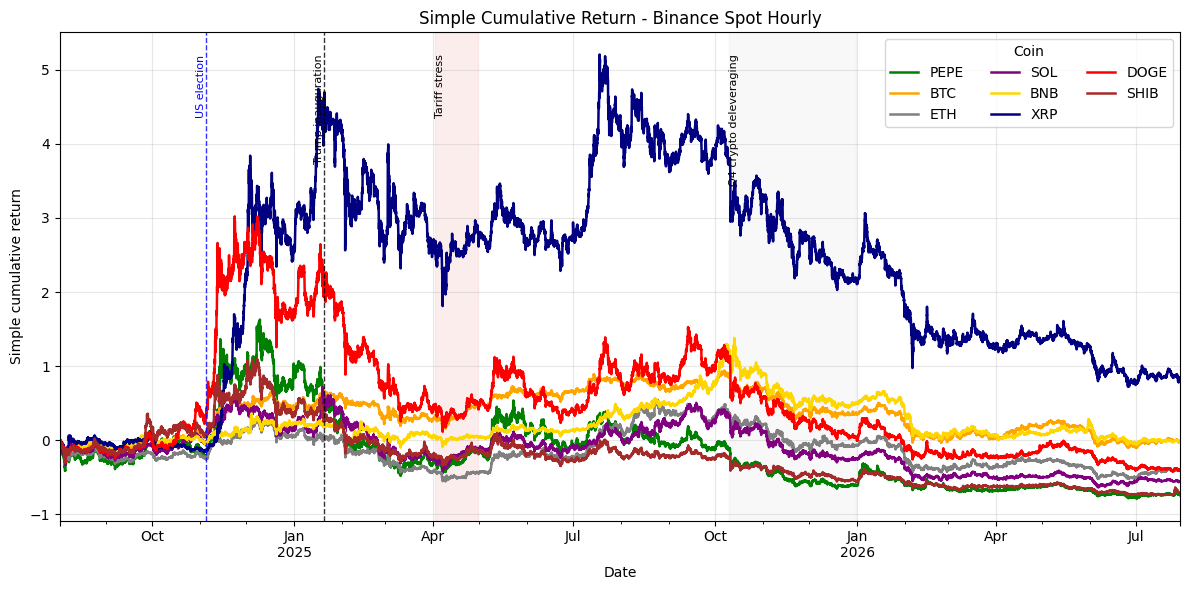

In [32]:
print("Simple cumulative return:")
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(simple_cumulative_returns.tail())
print()

plot_cumulative_returns(
    simple_cumulative_returns,
    coin_colors,
    title="Simple Cumulative Return - Binance Spot Hourly",
    ylabel="Simple cumulative return",
    ncols=3,
)


## Build lagged trading feature matrix


In [33]:
# Build lagged feature matrix for trading-style hourly forecast testing
# - target PEPE is the current hourly log return
# - predictors are lagged so they use information known before the target hour
features, model_data, trading_indicator_table = build_trading_features(target, peer_coins, market_data)

print(f"Number of model features: {features.shape[1]}")
print()
print("Model data:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.expand_frame_repr", False,
):
    print(model_data.head(10))
print()
print("Trading indicators:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.expand_frame_repr", False,
):
    print(trading_indicator_table.head())
print()
print("Dependent Variable is current-hour PEPE log return.")
print("All predictors are lagged to avoid using information from the target hour.")
print("FRED macro series are lower frequency and forward-filled onto hourly timestamps.")


Number of model features: 35

Model data:
                               PEPE  BTC_lag1  ETH_lag1  SOL_lag1  BNB_lag1  XRP_lag1  DOGE_lag1  SHIB_lag1  PEPE_lag1  PEPE_lag2  PEPE_lag3  PEPE_lag5  PEPE_momentum_7h_lag1  PEPE_momentum_14h_lag1  PEPE_volatility_7h_lag1  PEPE_volatility_14h_lag1  PEPE_volume_change_lag1  PEPE_range_lag1  BTC_volatility_14h_lag1  BTC_range_lag1  BTC_funding_rate_sum_lag1  BTC_DVOL_change_lag1  M2_30d_change_lag1  SOFR_change_lag1  DFF_change_lag1  QQQ_lag1  SPY_lag1  IEF_lag1  TLT_lag1  UUP_lag1  HYG_lag1  VXX_lag1  PEPE_SMA12h_lag1  PEPE_SMA26h_lag1  PEPE_RSI_14h_lag1  PEPE_BB_percent_b_20h_lag1
timestamp                                                                                                                                                                                                                                                                                                                                                                       

In [34]:
print(features.isna().sum().sort_values(ascending=False).to_string())


M2_30d_change_lag1            1441
PEPE_SMA26h_lag1                26
PEPE_BB_percent_b_20h_lag1      20
HYG_lag1                        15
PEPE_RSI_14h_lag1               15
VXX_lag1                        15
QQQ_lag1                        15
IEF_lag1                        15
SPY_lag1                        15
TLT_lag1                        15
UUP_lag1                        15
PEPE_momentum_14h_lag1          14
BTC_volatility_14h_lag1         14
PEPE_volatility_14h_lag1        14
PEPE_SMA12h_lag1                12
PEPE_volatility_7h_lag1          7
PEPE_momentum_7h_lag1            7
PEPE_lag5                        5
PEPE_lag3                        3
SOFR_change_lag1                 2
DFF_change_lag1                  2
BTC_DVOL_change_lag1             2
PEPE_lag2                        2
PEPE_volume_change_lag1          2
SOL_lag1                         1
BTC_lag1                         1
ETH_lag1                         1
BTC_range_lag1                   1
PEPE_range_lag1     

## Fit forecast models


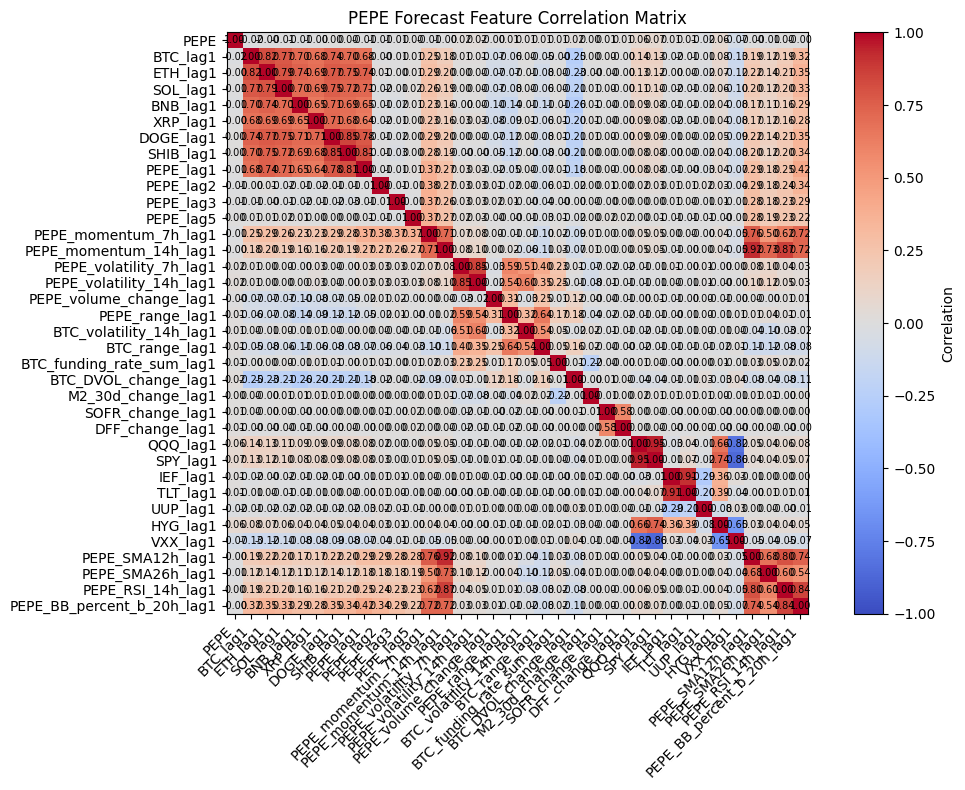

In [35]:
plot_correlation_matrix(model_data, "PEPE Forecast Feature Correlation Matrix")


## Regression fit diagnostics


In [36]:
# Linear, Ridge, and ElasticNet regression
feature_columns = list(features.columns)
model_result = fit_regression_models(model_data, target, feature_columns)

feature_columns = model_result["feature_columns"]
train_data = model_result["train_data"]
test_data = model_result["test_data"]
X_train = model_result["X_train"]
X_test = model_result["X_test"]
y_train = model_result["y_train"]
y_test = model_result["y_test"]
model = model_result["model"]
y_pred = model_result["y_pred"]
ridge_model = model_result["ridge_model"]
ridge_y_pred = model_result["ridge_y_pred"]
elastic_net_model = model_result["elastic_net_model"]
elastic_net_y_pred = model_result["elastic_net_y_pred"]
model_accuracy_comparison = model_result["model_accuracy_comparison"]
model_comparison = model_result["model_comparison"]
elastic_net_coefficients = model_result["elastic_net_coefficients"]
elastic_net_selected_coefficients = model_result["elastic_net_selected_coefficients"]
metrics_by_model = model_accuracy_comparison.set_index("model")

print()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                   PEPE   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     3.772
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           4.23e-13
Time:                        18:29:27   Log-Likelihood:                 37525.
No. Observations:               12793   AIC:                        -7.498e+04
Df Residuals:                   12757   BIC:                        -7.471e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const              

### Model accuracy comparison and ElasticNet coefficients

Elastic Net coefficients are shown directly below the model comparison so the selected features are easy to inspect.


In [37]:
print("Model accuracy comparison")
print(model_accuracy_comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

print()
print("ElasticNet selected coefficients")
print(elastic_net_selected_coefficients.to_string(index=False, float_format=lambda value: f"{value:.6g}"))


Model accuracy comparison
     model        alpha  l1_ratio  nonzero_coefficients  train_r2  adjusted_train_r2   test_r2  adjusted_test_r2     rmse  prediction_correlation  cv_r2_mean
       OLS          NaN       NaN                    35  0.010244           0.007528 -0.009707         -0.020880 0.008236                0.037162   -0.016648
     Ridge 10000.000000       NaN                    35  0.008013           0.005291 -0.001227         -0.012306 0.008201                0.042092    0.001707
ElasticNet     0.001000  0.500000                     2  0.003466           0.000732  0.002371         -0.008668 0.008187                0.050304    0.000973

ElasticNet selected coefficients
 feature  coefficient  abs_coefficient
SPY_lag1  0.000217133      0.000217133
VXX_lag1 -0.000200515      0.000200515


## Strategy results, cumulative returns, and trades


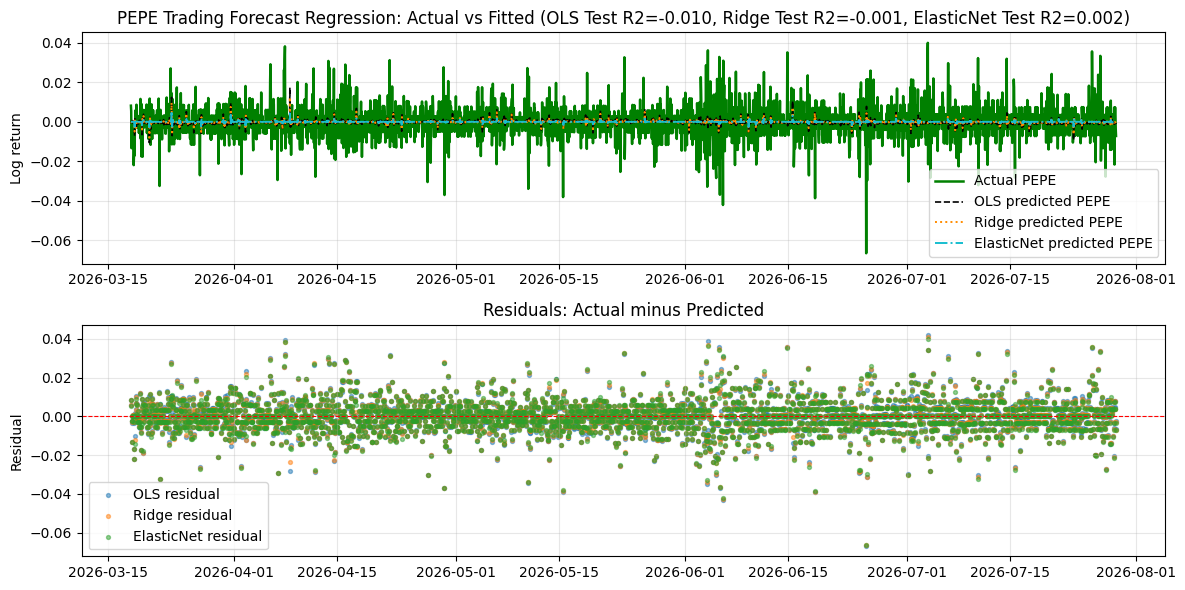

In [38]:
predictions = {
    "OLS": y_pred,
    "Ridge": ridge_y_pred,
    "ElasticNet": elastic_net_y_pred,
}
plot_regression_fit(
    test_data,
    y_test,
    predictions,
    target=target,
    target_color=coin_colors[target],
    title=(
        f"PEPE Trading Forecast Regression: Actual vs Fitted "
        f"(OLS Test R2={metrics_by_model.loc['OLS', 'test_r2']:.3f}, "
        f"Ridge Test R2={metrics_by_model.loc['Ridge', 'test_r2']:.3f}, "
        f"ElasticNet Test R2={metrics_by_model.loc['ElasticNet', 'test_r2']:.3f})"
    ),
)


## Trading Backtest Results OOS


Test start: 2026-03-18
Test end: 2026-07-29

Strategy metrics table
     model  trade_number  cumulative_return      cagr  sharpe_ratio  max_drawdown  variance  sortino_ratio  directional_accuracy
       OLS           985           0.833771  4.261778      2.164601     -0.314885  0.000067       2.986952              0.412316
     Ridge           861           1.277721  8.527168      2.939188     -0.281219  0.000067       4.145966              0.422319
ElasticNet           381           2.127755 21.705093      4.073397     -0.227572  0.000067       5.806681              0.424195


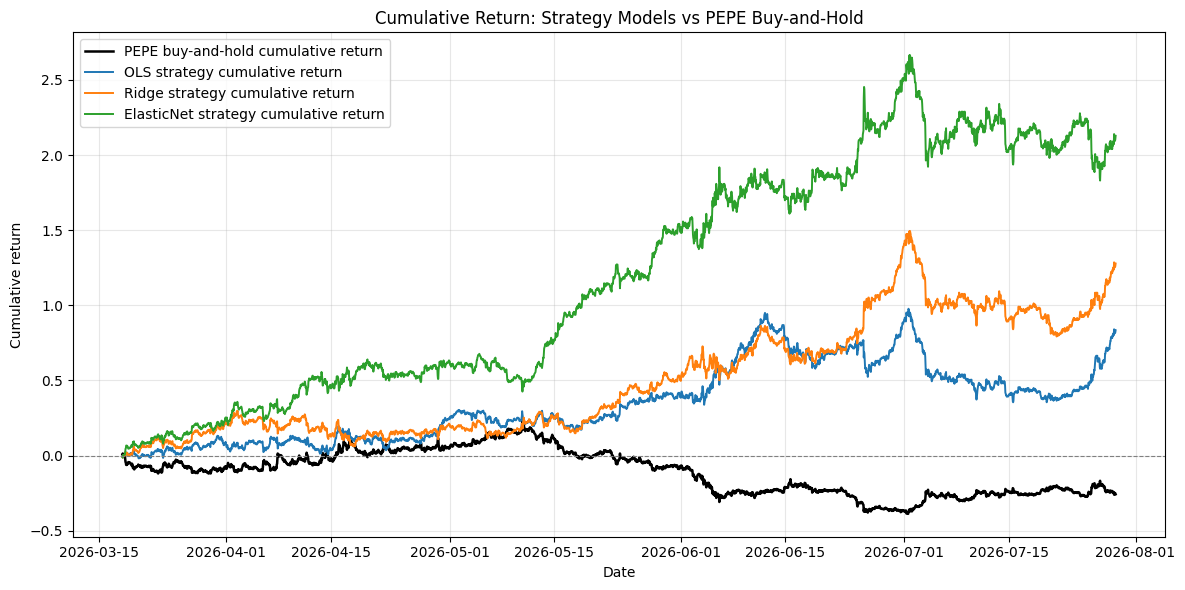

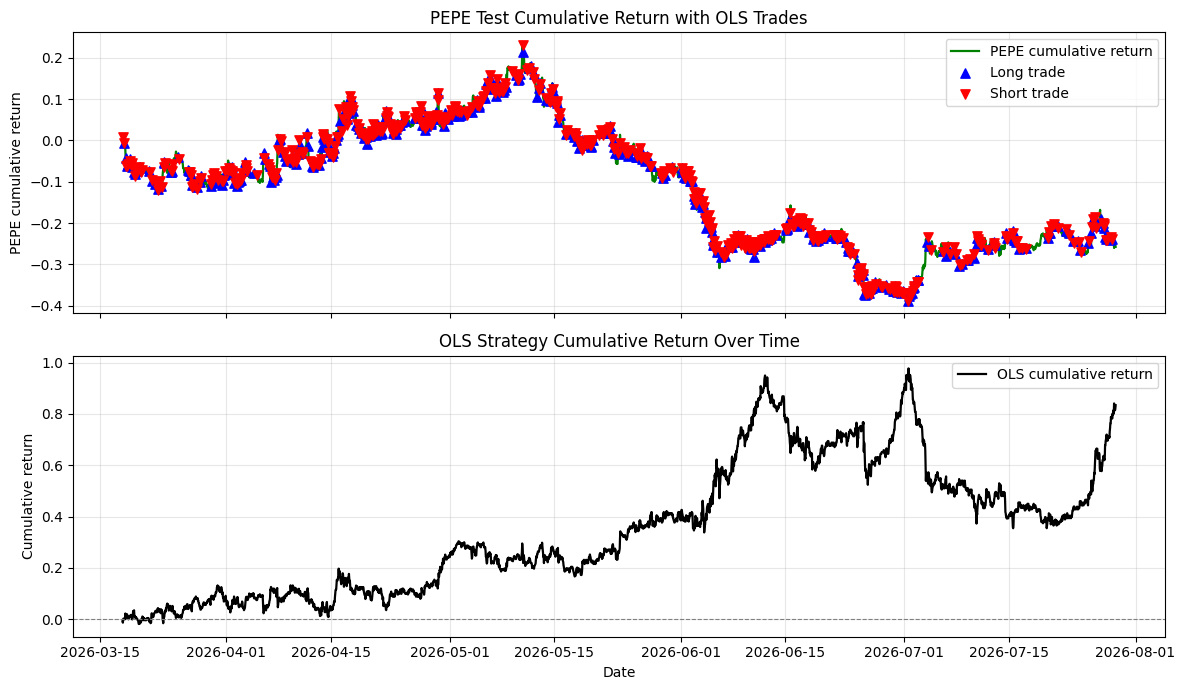

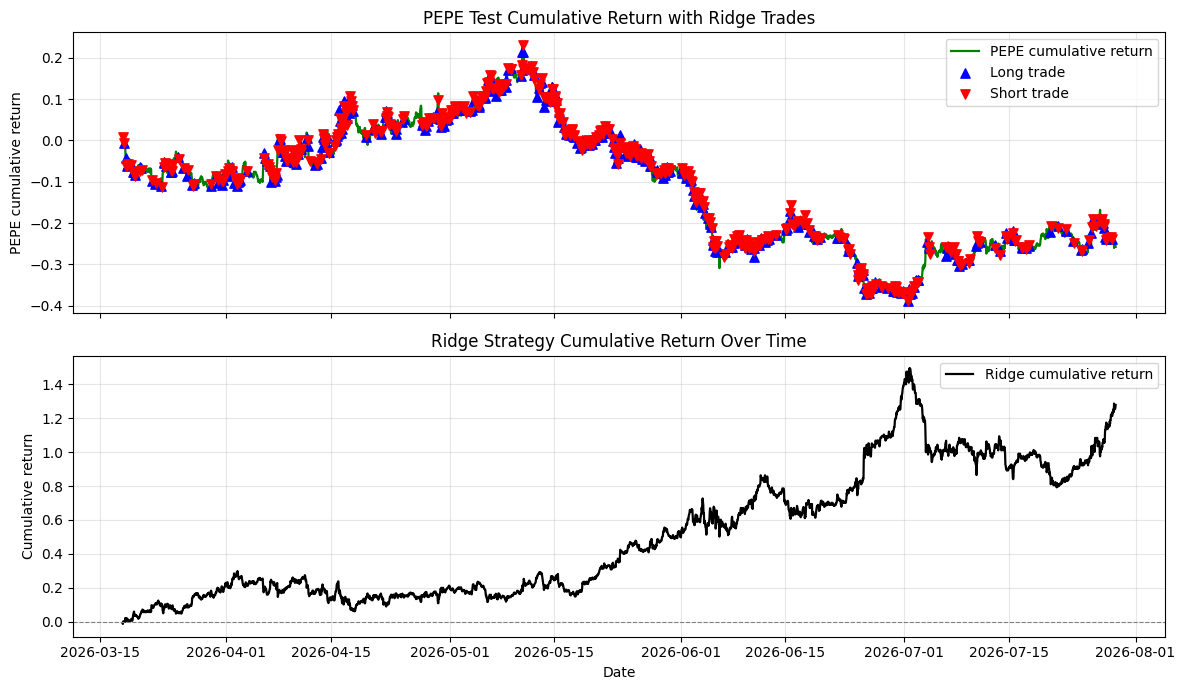

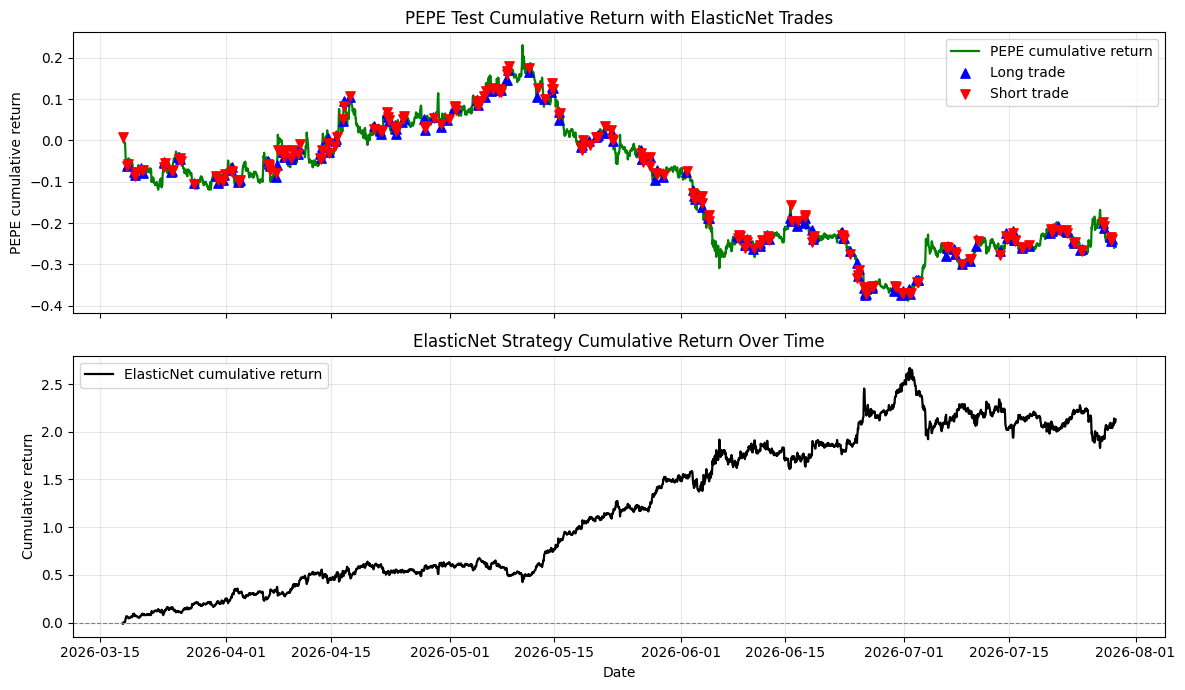

In [39]:
annual_periods = 24 * 365
prediction_sets = {
    "OLS": pd.Series(y_pred, index=y_test.index),
    "Ridge": pd.Series(ridge_y_pred, index=y_test.index),
    "ElasticNet": pd.Series(elastic_net_y_pred, index=y_test.index),
}
strategy_metrics, model_trade_comparison, strategy_series = run_strategy_backtest(
    y_test,
    prediction_sets,
    annual_periods=annual_periods,
)

PEPE_test_cumulative_returns = np.exp(y_test.cumsum()) - 1
PEPE_buy_hold_cumulative_return = PEPE_test_cumulative_returns.iloc[-1] if len(PEPE_test_cumulative_returns) else np.nan

test_start = y_test.index.min().date()
test_end = y_test.index.max().date()
print(f"Test start: {test_start}")
print(f"Test end: {test_end}")
print()
print("Strategy metrics table")
print(model_trade_comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    PEPE_test_cumulative_returns.index,
    PEPE_test_cumulative_returns,
    label="PEPE buy-and-hold cumulative return",
    color="black",
    linewidth=1.8,
)
for model_name, model_strategy in strategy_series.items():
    ax.plot(
        model_strategy.index,
        model_strategy["strategy_cumulative_pnl"],
        label=f"{model_name} strategy cumulative return",
        linewidth=1.4,
    )
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Return: Strategy Models vs PEPE Buy-and-Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for model_name, model_strategy in strategy_series.items():
    trade_log = model_strategy.loc[model_strategy["trade_event"]].copy()
    long_trades = trade_log[trade_log["signal"].eq(1)]
    short_trades = trade_log[trade_log["signal"].eq(-1)]
    flat_trades = trade_log[trade_log["signal"].eq(0)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(
        PEPE_test_cumulative_returns.index,
        PEPE_test_cumulative_returns,
        label="PEPE cumulative return",
        color=coin_colors[target],
        linewidth=1.6,
    )
    axes[0].scatter(
        long_trades.index,
        PEPE_test_cumulative_returns.reindex(long_trades.index),
        marker="^",
        color="blue",
        s=45,
        label="Long trade",
        zorder=3,
    )
    axes[0].scatter(
        short_trades.index,
        PEPE_test_cumulative_returns.reindex(short_trades.index),
        marker="v",
        color="red",
        s=45,
        label="Short trade",
        zorder=3,
    )
    if not flat_trades.empty:
        axes[0].scatter(
            flat_trades.index,
            PEPE_test_cumulative_returns.reindex(flat_trades.index),
            marker="o",
            color="black",
            s=28,
            label="Flat trade",
            zorder=3,
        )
    axes[0].set_title(f"PEPE Test Cumulative Return with {model_name} Trades")
    axes[0].set_ylabel("PEPE cumulative return")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        model_strategy.index,
        model_strategy["strategy_cumulative_pnl"],
        label=f"{model_name} cumulative return",
        color="black",
        linewidth=1.6,
    )
    axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
    axes[1].set_title(f"{model_name} Strategy Cumulative Return Over Time")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Cumulative return")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## Notebook-only outputs

This notebook displays model accuracy, strategy metrics, trade markers, PnL charts, and diagnostics inline. It does not save forecast CSV, TXT, or PNG output files.